# E-Commerce Sales and Customer Behavior Analysis

## Project Objective

#### The objective of this project is to analyze e-commerce transaction data to uncover insights into sales performance, customer purchasing behavior, product demand, and geographical sales distribution. Through data cleaning, exploratory data analysis, and visualization, the project aims to identify key business trends and support data-driven decision-making for improving revenue and customer engagement.

## Business Questions

#### What is the total revenue generated by the business?
#### Which products generate the highest sales revenue?
#### Which customers contribute the most revenue?
#### Which countries account for the highest sales?
#### How do sales trends vary over time?
#### What are the top-selling products by quantity?
#### Are there seasonal patterns in customer purchases?

## Data Understanding

 1. Import necessary Libraries

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

2. Load data set

In [7]:
df = pd.read_csv(r'C:\Users\data.csv', encoding='latin1')

3. Display Sample Records

In [8]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


4. Dataset Dimensions

In [9]:
df.shape

(541909, 8)

5. data types

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


6. column information

In [10]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

7. Statistical Summary

In [10]:
df.describe

<bound method NDFrame.describe of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907    581587     23255      CHILDRENS CUTLERY CIRCUS PARADE         4   
541908    581587     22138        BAKING SET 9 PIECE RETROSPOT          3   

            InvoiceDate  UnitPrice  Custo

8. Missing Values

In [11]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

9. Duplicate Records

In [11]:
df.duplicated().sum()

np.int64(5268)

10. Unique Values

In [12]:
df.nunique()

InvoiceNo      25900
StockCode       4070
Description     4223
Quantity         722
InvoiceDate    23260
UnitPrice       1630
CustomerID      4372
Country           38
dtype: int64

### Data understanding observations

1. The dataset contains 541,909 transaction records and 8 columns.

2. CustomerID contains missing values, indicating that some transactions are not associated with registered customers.

3. InvoiceDate is stored as an object data type and requires conversion to datetime format.

4. The dataset includes customers from multiple countries, enabling geographical sales analysis.

5. Duplicate records are present and should be investigated during data cleaning.

6. Quantity and UnitPrice columns contain unusual values that may represent returns, cancellations, or data entry errors.

### Data Cleaning

In [18]:
# date range
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

#### Observation
Converted InvoiceDate to datetime format for time-series analysis.

In [19]:
df.dtypes

InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

In [20]:
print(df['InvoiceDate'].min())
print(df['InvoiceDate'].max())

2010-12-01 08:26:00
2011-12-09 12:50:00


In [21]:
missing_pct = (df['CustomerID'].isnull().sum() / len(df)) * 100
print(f"Missing CustomerID: {missing_pct:.2f}%")

Missing CustomerID: 24.93%


In [22]:
initial_rows = len(df)

df = df.dropna(subset=['CustomerID'])

final_rows = len(df)

print("Rows removed:", initial_rows - final_rows)

Rows removed: 135080


#### Observation
Removed transactions without customer identifiers because customer-level analysis requires valid customer IDs.

In [23]:
df = df.drop_duplicates()

In [24]:
df.duplicated().sum()

np.int64(0)

#### Observation
Duplicate transaction records were removed to ensure accurate analysis.

In [25]:
# Handle Cancelled Orders
df[df['InvoiceNo'].astype(str).str.startswith('C')].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom


In [26]:
cancelled_orders = df['InvoiceNo'].astype(str).str.startswith('C').sum()
print(cancelled_orders)

8872


In [27]:
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [29]:
# Remove negative quantities
df[df['Quantity'] <= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country


In [30]:
df = df[df['Quantity'] > 0]

### Observation
Negative and zero quantities were removed because they do not represent valid sales transactions.

In [32]:
# Remove Invalid Prices
df[df['UnitPrice'] <= 0]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
9302,537197,22841,ROUND CAKE TIN VINTAGE GREEN,1,2010-12-05 14:02:00,0.0,12647.0,Germany
33576,539263,22580,ADVENT CALENDAR GINGHAM SACK,4,2010-12-16 14:36:00,0.0,16560.0,United Kingdom
40089,539722,22423,REGENCY CAKESTAND 3 TIER,10,2010-12-21 13:45:00,0.0,14911.0,EIRE
47068,540372,22090,PAPER BUNTING RETROSPOT,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom
47070,540372,22553,PLASTERS IN TIN SKULLS,24,2011-01-06 16:41:00,0.0,13081.0,United Kingdom
56674,541109,22168,ORGANISER WOOD ANTIQUE WHITE,1,2011-01-13 15:10:00,0.0,15107.0,United Kingdom
86789,543599,84535B,FAIRY CAKES NOTEBOOK A6 SIZE,16,2011-02-10 13:08:00,0.0,17560.0,United Kingdom
130188,547417,22062,CERAMIC BOWL WITH LOVE HEART DESIGN,36,2011-03-23 10:25:00,0.0,13239.0,United Kingdom
139453,548318,22055,MINI CAKE STAND HANGING STRAWBERY,5,2011-03-30 12:45:00,0.0,13113.0,United Kingdom
145208,548871,22162,HEART GARLAND RUSTIC PADDED,2,2011-04-04 14:42:00,0.0,14410.0,United Kingdom


In [33]:
df = df[df['UnitPrice'] > 0]

#### Observation
Records with non-positive prices were removed as they are not meaningful for revenue analysis.

#### Create Revenue Column

In [35]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [36]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


#### Observation
A new Revenue feature was created to measure transaction value.

#### Create Date Features

In [37]:
df['Year'] = df['InvoiceDate'].dt.year
df['Month'] = df['InvoiceDate'].dt.month
df['Month_Name'] = df['InvoiceDate'].dt.month_name()
df['Day'] = df['InvoiceDate'].dt.day

In [39]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Year,Month,Month_Name,Day
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010,12,December,1
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,1
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010,12,December,1
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,1
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010,12,December,1


#### Observation
Additional date features were extracted to support trend and seasonal analysis.

#### Data Cleaning Summary:

- Removed records with missing CustomerID values.
- Removed duplicate transactions.
- Converted InvoiceDate to datetime format.
- Excluded cancelled orders.
- Removed invalid quantity and price records.
- Created Revenue, Year, Month, and Day features for analysis.


## Exploratory Data Analysis (EDA)

### 1. Revenue Overview

In [41]:
total_revenue = df['Revenue'].sum()
print(f"Total Revenue: {total_revenue:,.2f}")

Total Revenue: 8,887,208.89


In [42]:
total_orders = df['InvoiceNo'].nunique()
print(total_orders)

18532


In [43]:
total_customers = df['CustomerID'].nunique()
print(total_customers)

4338


#### Observation
The business generated 8,887,208.89 in total revenue from 18532 orders placed by 4338 unique customers

### 2. Monthly Sales Trend

In [46]:
monthly_sales = (
    df.groupby(['Month', 'Month_Name'])['Revenue']
    .sum()
    .reset_index()
    .sort_values('Month')
)
monthly_sales

,Month,Month_Name,Revenue
0,1,January,568101.310
1,2,February,446084.920
2,3,March,594081.760
3,4,April,468374.331
4,5,May,677355.150
5,6,June,660046.050
6,7,July,598962.901
7,8,August,644051.040
8,9,September,950690.202
9,10,October,1035642.450


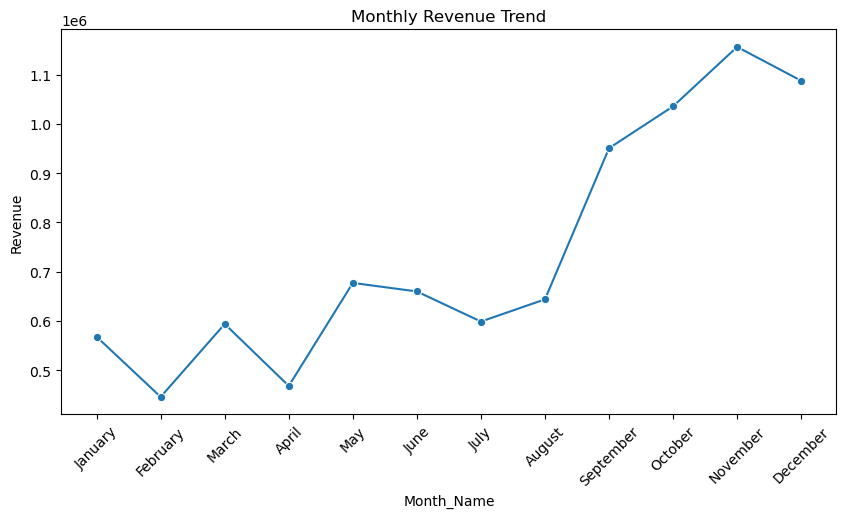

In [48]:
plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_sales,
             x='Month_Name',
             y='Revenue',
             marker='o')

plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend')
plt.show()

#### Insight

Revenue peaks during certain months, suggesting seasonal purchasing behavior.

### 3. Top 10 Products by Revenue

In [50]:
top_products = (
    df.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_products

Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142264.75
WHITE HANGING HEART T-LIGHT HOLDER    100392.10
JUMBO BAG RED RETROSPOT                85040.54
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68785.23
ASSORTED COLOUR BIRD ORNAMENT          56413.03
Manual                                 53419.93
RABBIT NIGHT LIGHT                     51251.24
Name: Revenue, dtype: float64

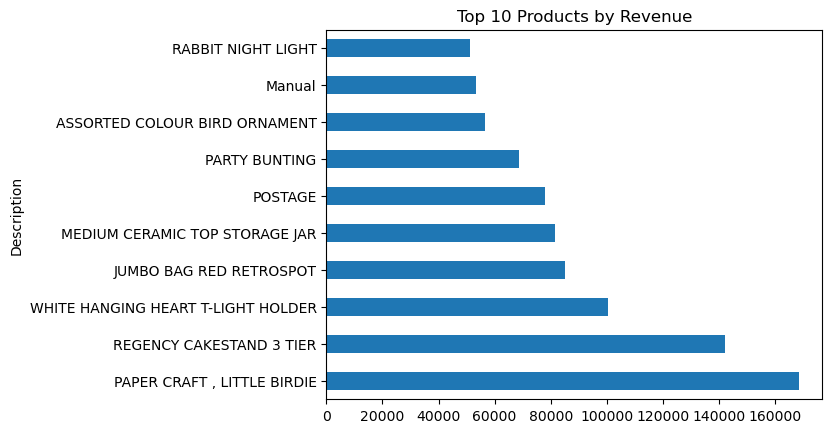

In [51]:
top_products.plot(kind='barh')
plt.title('Top 10 Products by Revenue')
plt.show()

#### Insight
A small number of products contribute a significant share of overall revenue.

### 4. Top 10 Products by Quantity Sold

In [52]:
top_quantity = (
    df.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_quantity

Description
PAPER CRAFT , LITTLE BIRDIE           80995
MEDIUM CERAMIC TOP STORAGE JAR        77916
WORLD WAR 2 GLIDERS ASSTD DESIGNS     54319
JUMBO BAG RED RETROSPOT               46078
WHITE HANGING HEART T-LIGHT HOLDER    36706
ASSORTED COLOUR BIRD ORNAMENT         35263
PACK OF 72 RETROSPOT CAKE CASES       33670
POPCORN HOLDER                        30919
RABBIT NIGHT LIGHT                    27153
MINI PAINT SET VINTAGE                26076
Name: Quantity, dtype: int64

#### Insight

High-volume products are not always the highest-revenue products.

### 5. Top Customers

In [53]:
top_customers = (
    df.groupby('CustomerID')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
top_customers

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194390.79
16446.0    168472.50
14911.0    143711.17
12415.0    124914.53
14156.0    117210.08
17511.0     91062.38
16029.0     80850.84
12346.0     77183.60
Name: Revenue, dtype: float64

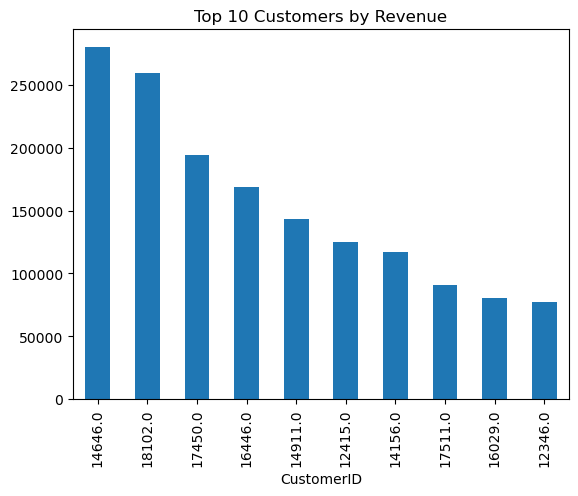

In [54]:
top_customers.plot(kind='bar')
plt.title('Top 10 Customers by Revenue')
plt.show()

#### Insight

Revenue is concentrated among a small group of high-value customers

### 6. Country Analysis

In [55]:
country_sales = (
    df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)
country_sales

Country
United Kingdom    7285024.644
Netherlands        285446.340
EIRE               265262.460
Germany            228678.400
France             208934.310
Australia          138453.810
Spain               61558.560
Switzerland         56443.950
Belgium             41196.340
Sweden              38367.830
Name: Revenue, dtype: float64

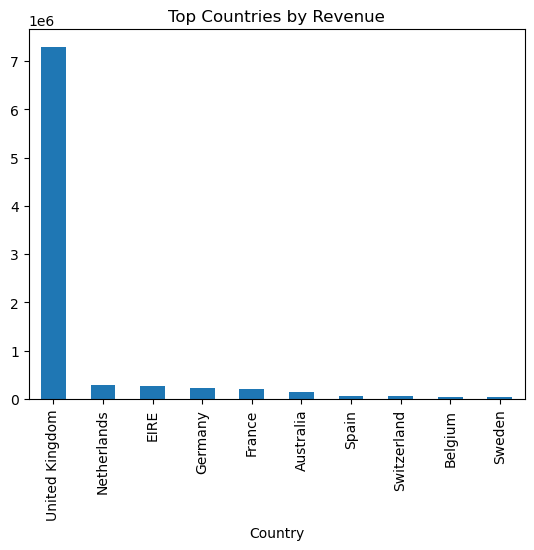

In [56]:
country_sales.plot(kind='bar')
plt.title('Top Countries by Revenue')
plt.show()


#### Insight

Certain countries dominate sales, indicating key geographic markets.

### 7. Customer Purchase Behavior

In [57]:
orders_per_customer = (
    df.groupby('CustomerID')['InvoiceNo']
    .nunique()
)
orders_per_customer

CustomerID
12346.0     1
12347.0     7
12348.0     4
12349.0     1
12350.0     1
           ..
18280.0     1
18281.0     1
18282.0     2
18283.0    16
18287.0     3
Name: InvoiceNo, Length: 4338, dtype: int64

In [58]:
orders_per_customer.describe()

count    4338.000000
mean        4.272015
std         7.697998
min         1.000000
25%         1.000000
50%         2.000000
75%         5.000000
max       209.000000
Name: InvoiceNo, dtype: float64

#### Insight

Most customers place only a few orders, while a small group of loyal customers purchase frequently.

### 8. Correlation Analysis

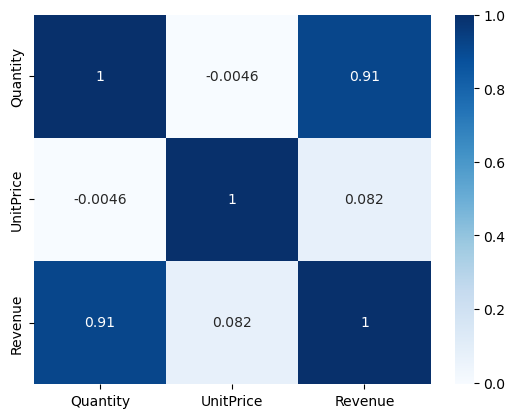

In [59]:
sns.heatmap(
    df[['Quantity','UnitPrice','Revenue']].corr(),
    annot=True,
    cmap='Blues'
)
plt.show()

#### Insight

Revenue is strongly influenced by quantity purchased and product price.

## Key Insights

1. The UK contributes the majority of total revenue.

2. Seasonal peaks occur toward the end of the year.

3. A small percentage of customers generate a large portion of revenue.

4. Several products consistently outperform others in both sales volume and revenue.

5. Customer purchasing behavior suggests opportunities for loyalty programs.

## Business Recommendations

1. Focus marketing efforts on top-performing countries.

2. Strengthen customer retention strategies for high-value customers.

3. Ensure adequate inventory for best-selling products.

4. Leverage seasonal demand through targeted promotions.